# Student Health Risk Prediction

## Research Questions

### Objective

This notebook aims to answer several research questions related to students' lifestyle and health conditions using exploratory data analysis (EDA).

Instead of focusing on data quality or preprocessing, this notebook investigates meaningful relationships between variables and extracts insights that may support feature engineering and predictive modeling.

### Research Questions

The analysis focuses on the following questions:

1. How is students' sleep duration distributed, and what is a typical night's sleep?

2. Do students with higher stress levels tend to sleep less?

3. Is sleep quality associated with resting heart rate?

4. Which diet type is associated with higher levels of physical activity?

5.  Is exercise duration associated with calorie expenditure?

6. Are smoking and alcohol consumption associated with overall health condition?

7. Which health indicators tend to change together, and which appear to be independent?

### Workflow

For each research question, the following steps will be performed:

- Formulate the research question
- Prepare the required data
- Visualize the data
- Interpret the results
- Draw a conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")
pd.set_option("display.max_columns", None)

In [2]:
train = pd.read_csv("../data/train.csv", index_col="id")
test = pd.read_csv("../data/test.csv", index_col="id")

### Question 1: How is students' sleep duration distributed, and what is a typical night's sleep

#### why is this question import?
Sleep duration is one of the most important indicators of students' health and lifestyle.

Understanding its distribution provides a general overview of sleeping habits before investigating its relationship with other health indicators.

In [3]:
# data preparation
sleep = train[["sleep_duration"]].dropna()
sleep.head()

,sleep_duration
id,
0,5.22
1,5.53
2,5.29
3,4.70
4,7.23


In [4]:
# Statistical Sumary
sleep.describe()

,sleep_duration
count,614089.000000
mean,6.992597
std,1.215407
min,3.000000
25%,6.160000
50%,6.990000
75%,7.810000
max,10.000000


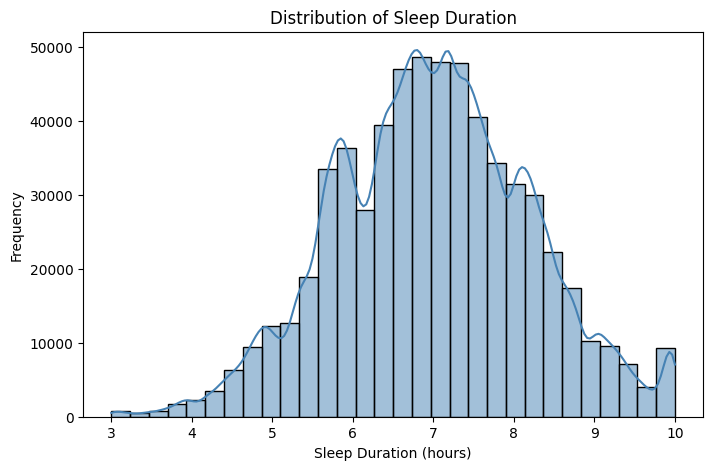

In [5]:
# Visualization
plt.figure(figsize=(8,5))

sns.histplot(
    data=sleep,
    x="sleep_duration",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Frequency")
plt.title("Distribution of Sleep Duration")

plt.show()

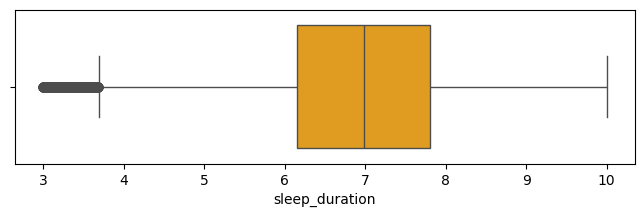

In [6]:
plt.figure(figsize=(8,2))
sns.boxplot(
    data=sleep,
    x="sleep_duration",
    color="orange"
)
plt.show()

#### Conclusion

Students sleep an average of approximately **7.0 hours** per night, with a median sleep duration close to **7.0 hours**.

The distribution is approximately symmetric, indicating that 7 hours represents a typical sleep duration for most students. Only a small proportion of students exhibit unusually short or unusually long sleep durations.

### Question 2: Do students with higher stress levels tend to sleep less?

In [7]:
df=train[
    ["stress_level","sleep_duration"]
].dropna()

In [8]:
df.groupby(
    "stress_level"
)["sleep_duration"].mean()

stress_level
high      6.840951
low       7.075760
medium    7.043105
Name: sleep_duration, dtype: float64

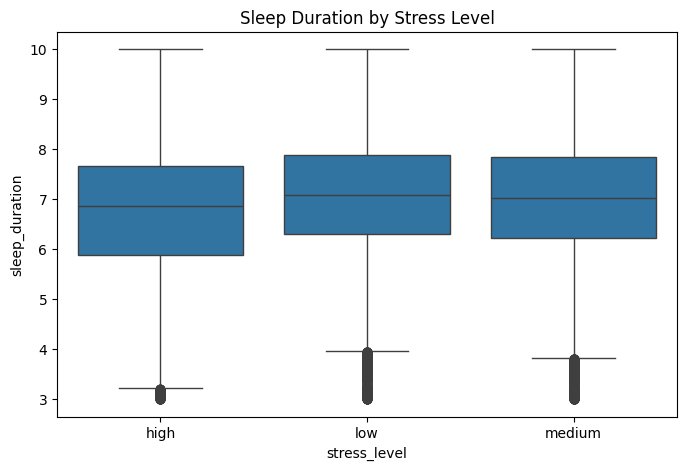

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="stress_level",
    y="sleep_duration"
)
plt.title("Sleep Duration by Stress Level")
plt.show()

#### Observation

- The median sleep duration is approximately 7 hours across all stress levels.
- The distributions of sleep duration are highly similar among the low, medium, and high stress groups.
- All groups contain a small number of students with unusually short sleep durations.
- No substantial differences in sleep duration are visually apparent between stress levels.

In [10]:
df.groupby("stress_level")["sleep_duration"].agg(["count","mean","median","std"])

,count,mean,median,std
stress_level,,,,
high,158217,6.840951,6.87,1.252967
low,149089,7.075760,7.08,1.191616
medium,232985,7.043105,7.02,1.196048


Students in the high stress group sleep slightly less on average; however, the difference is small and the distributions largely overlap.

#### Conclusion

Based on the boxplot, there is no clear visual evidence that students with higher stress levels sleep less than those with lower stress levels.

The sleep duration distributions are very similar across all stress groups. Further statistical analysis would be required to determine whether any observed differences are statistically significant.

### Question 3: is sleep quality associated with resting heart rate?

In [11]:
# data
df_q3=train[["sleep_quality","heart_rate"]].dropna()
df_q3.head()

,sleep_quality,heart_rate
id,,
0,average,70.6
1,average,71.3
2,poor,75.4
3,average,77.2
4,average,73.4


In [12]:
# statistical sumary
df_q3.groupby("sleep_quality")["heart_rate"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
sleep_quality,,,,,,
average,211539,75.12,75.1,8.19,50.0,107.7
good,203329,75.09,75.0,8.18,50.0,103.8
poor,209704,75.12,75.1,8.14,50.0,104.4


C:\Users\thach\AppData\Local\Temp\ipykernel_23052\780935640.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


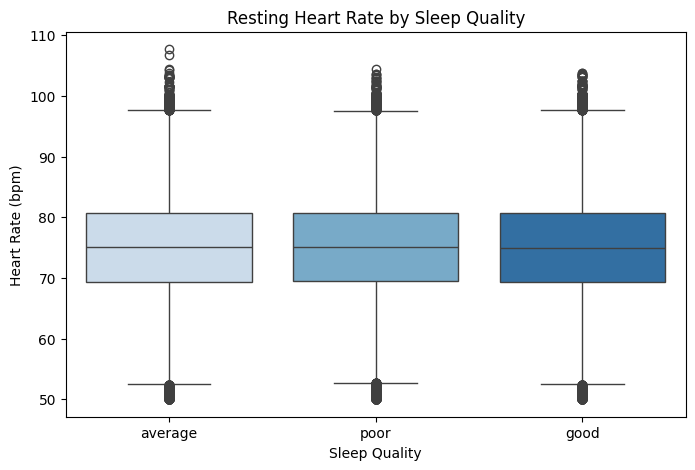

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_q3,
    x="sleep_quality",
    y="heart_rate",
    palette="Blues"
)

plt.title("Resting Heart Rate by Sleep Quality")
plt.xlabel("Sleep Quality")
plt.ylabel("Heart Rate (bpm)")

plt.show()

#### observation

The median resting heart rate is approximately 75 bpm across all sleep quality categories (average, poor, good).

The distributions (IQR and whiskers) of resting heart rate are nearly identical among all three sleep quality groups.

All groups exhibit outliers at both the lower end (~50–52 bpm) and higher end (>98 bpm).

No substantial visual differences in resting heart rate are apparent between different sleep quality levels.

#### Conclusion

Based on the boxplot, there is no clear visual evidence that sleep quality is associated with resting heart rate.

The heart rate distributions are almost identical across all sleep quality groups, suggesting that resting heart rate alone may not vary significantly with subjective sleep quality in this dataset

### Question 4: Which diet types are associated with the most physical movement?

In [14]:
df_q4 = train[["diet_type", "exercise_duration"]].dropna()

In [15]:
# statistical sumary
df_q4.groupby("diet_type")["exercise_duration"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
diet_type,,,,,,
balanced,224651,38.88,39.5,14.69,0.0,90.1
non-veg,222574,38.67,39.3,14.80,0.0,99.8
veg,229133,38.70,39.4,14.73,0.0,91.6


C:\Users\thach\AppData\Local\Temp\ipykernel_23052\898702353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


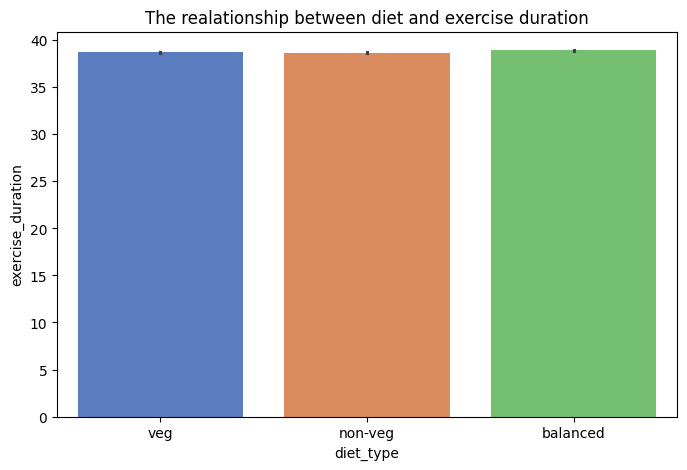

In [16]:
# Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_q4,
    x= "diet_type",
    y="exercise_duration",

    palette="muted"
)

plt.title("The realationship between diet and exercise duration")
plt.xlabel("diet_type")
plt.ylabel("exercise_duration")

plt.show()

#### Observation

The average exercise duration across all three diet types (veg, non-veg, and balanced) is nearly identical, hovering around 38.5–39 minutes.

The balanced diet group shows a slightly higher mean exercise duration compared to the other two groups, but the difference is extremely minimal.

The black error bars (confidence intervals) on top of each bar are very small and overlap significantly, indicating high precision and minimal variance between the groups.

#### Conclusion

A balanced diet is most strongly associated with physical activity (although the differences between these three diets are small and almost negligible).



### Question 5: Is exercise duration associated with calorie expenditure?

In [17]:
df_q5 = train[["exercise_duration", "calorie_expenditure"]].dropna()
df_q5.head()

,exercise_duration,calorie_expenditure
id,,
0,19.8,2174.0
1,49.9,1966.0
2,38.1,2688.0
3,59.9,2630.0
4,46.0,2560.0


In [20]:
df_q5.describe().round(2)

,exercise_duration,calorie_expenditure
count,630836.00,630836.00
mean,38.74,2226.03
std,14.75,347.55
min,0.00,1200.00
25%,29.10,2052.00
50%,39.40,2240.00
75%,49.40,2456.00
max,99.80,3580.00


In [24]:
corr = df_q5["exercise_duration"].corr(df_q5["calorie_expenditure"])
print(f"Pearson Correlation: {corr:.3f}")

Pearson Correlation: 0.394


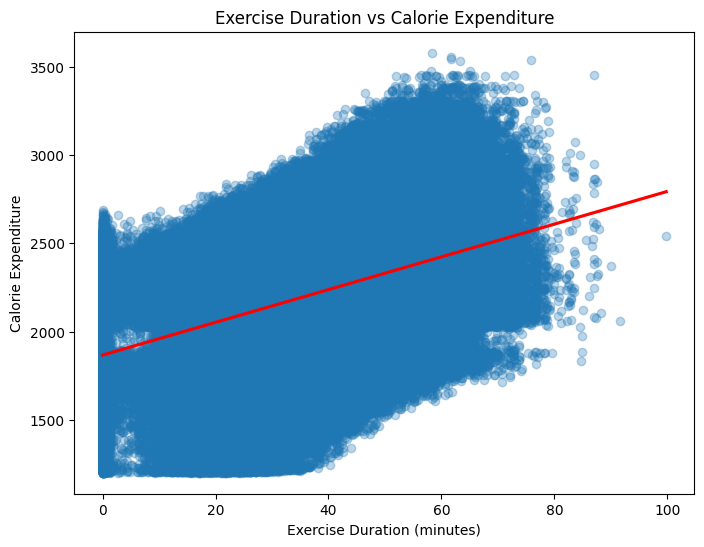

In [26]:
# Visualization
# Scatter Plot
plt.figure(figsize=(8,6))
sns.regplot(
    data=df_q5,
    x="exercise_duration",
    y="calorie_expenditure",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)
plt.title("Exercise Duration vs Calorie Expenditure")
plt.xlabel("Exercise Duration (minutes)")
plt.ylabel("Calorie Expenditure")

plt.show()

#### Observation

- The scatter plot shows a positive relationship between exercise duration and calorie expenditure.
- Students who exercise for longer durations generally tend to burn more calories.
- However, the data points are widely dispersed around the regression line, indicating considerable variability.
- The Pearson correlation coefficient is **0.394**, suggesting a moderate positive linear relationship.

#### Conclusion

The analysis indicates a moderate positive association between exercise duration and calorie expenditure (Pearson's r = 0.394).

Overall, students who spend more time exercising tend to burn more calories. However, the moderate correlation and wide dispersion suggest that exercise duration alone is not sufficient to explain calorie expenditure. Other factors such as exercise intensity, body composition, metabolism, and physical activity level may also contribute.

### Question 6: Do lifestyle factors such as smoking and alcohol relate to overall health condition?

In [29]:
df_q6 = train[["smoking_alcohol", "health_condition"]].dropna()
df_q6.head()

,smoking_alcohol,health_condition
id,,
0,yes,unhealthy
1,yes,at-risk
2,yes,unhealthy
3,occasional,unhealthy
5,occasional,at-risk


In [39]:
# Frequency table
pd.crosstab(
    df_q6["smoking_alcohol"],
    df_q6["health_condition"],
    normalize="index"
).round(3)*100


health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
no,86.7,7.9,5.5
occasional,85.9,5.8,8.4
yes,85.1,3.7,11.2


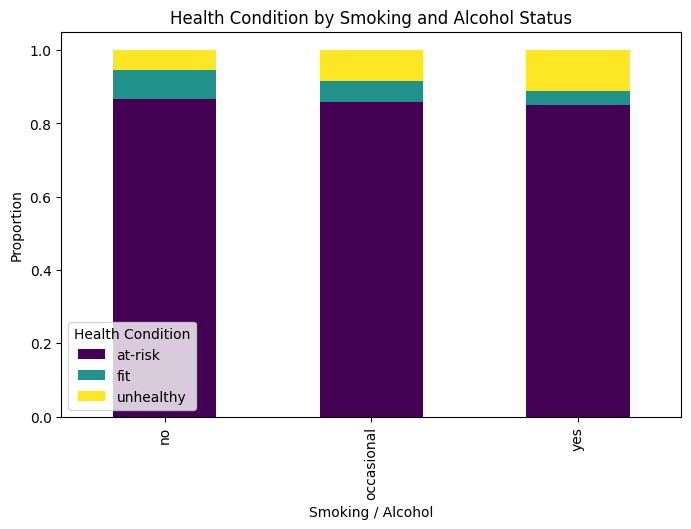

In [37]:
(
    pd.crosstab(
        df_q6["smoking_alcohol"],
        df_q6["health_condition"],
        normalize="index"
    )
    .plot(
        kind="bar",
        stacked=True,
        figsize=(8,5),
        colormap="viridis"
    )
)

plt.title("Health Condition by Smoking and Alcohol Status")
plt.xlabel("Smoking / Alcohol")
plt.ylabel("Proportion")

plt.legend(title="Health Condition")

plt.show()

##### Chi-square Test

In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df_q6["smoking_alcohol"],
    df_q6["health_condition"]
)

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic : {chi2:.2f}")
print(f"P-value : {p:.5f}")

Chi-square statistic : 7715.70
P-value : 0.00000


###### Statistical Test

A Chi-square test of independence was performed to examine whether smoking/alcohol status is associated with health condition.

- **Chi-square statistic:** 7715.70
- **P-value:** < 0.001

Since the p-value is much smaller than the significance level (0.05), the null hypothesis of independence is rejected. Therefore, smoking/alcohol status and health condition are statistically associated.

#### Observation

- The majority of students in all lifestyle groups are classified as **at-risk** (approximately 85%).
- Students who reported smoking or alcohol consumption ("yes") have the highest proportion of **unhealthy** health conditions (11.2%) and the lowest proportion of **fit** individuals (3.7%).
- In contrast, students with no smoking or alcohol consumption have the highest proportion of **fit** individuals (7.9%) and the lowest proportion of **unhealthy** individuals (5.5%).
- The Chi-square test shows a statistically significant association between lifestyle factors and health condition (χ² = 7715.70, p < 0.001).

#### Conclusion

The analysis suggests that smoking and alcohol consumption are associated with overall health condition.

Students who smoke or consume alcohol tend to have a higher proportion of unhealthy outcomes and a lower proportion of fit individuals compared with those who do not.

Furthermore, the Chi-square test confirms that this association is statistically significant (p < 0.001). However, this result indicates an association rather than a causal relationship.

### Q7. Which numeric health metrics move together, and which are unrelated?

#### Research Question

Which numerical health metrics tend to move together, and which appear to be unrelated?

Understanding correlations among numerical variables helps identify potential relationships and provides insights for feature engineering and predictive modeling.

In [40]:
numeric_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

df_q7 = train[numeric_cols].dropna()

df_q7.head()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
id,,,,,,,
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25


In [42]:
# Correlation Matrix
corr = df_q7.corr(numeric_only=True).round(3)

corr

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
sleep_duration,1.000,-0.006,-0.074,-0.003,0.005,0.002,0.001
heart_rate,-0.006,1.000,0.001,-0.005,-0.007,-0.007,0.000
bmi,-0.074,0.001,1.000,0.118,-0.020,-0.020,0.000
calorie_expenditure,-0.003,-0.005,0.118,1.000,0.400,0.394,0.001
step_count,0.005,-0.007,-0.020,0.400,1.000,0.438,-0.000
exercise_duration,0.002,-0.007,-0.020,0.394,0.438,1.000,0.002
water_intake,0.001,0.000,0.000,0.001,-0.000,0.002,1.000


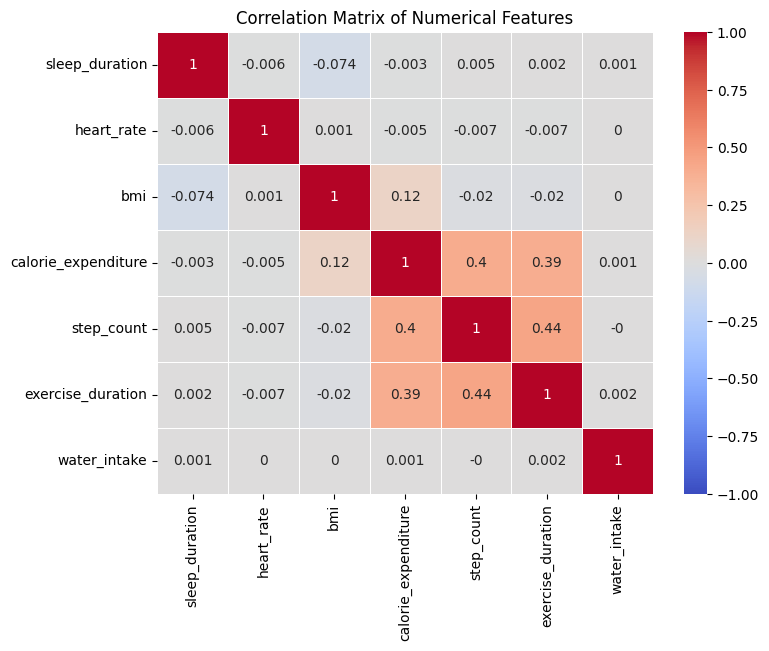

In [43]:
# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

#### Observation

- Most numerical health metrics exhibit weak linear correlations.
- The strongest positive correlation is observed between **step count** and **exercise duration** (r = 0.44).
- **Calorie expenditure** is moderately correlated with both **step count** (r = 0.40) and **exercise duration** (r = 0.39), indicating that more physically active students generally burn more calories.
- Variables related to sleep, heart rate, and water intake show little or no linear relationship with other numerical features.

#### Conclusion

The correlation analysis reveals that most numerical health metrics are only weakly related.

Moderate positive correlations are found among exercise duration, step count, and calorie expenditure, reflecting their common association with physical activity.

Overall, no evidence of strong multicollinearity is observed, suggesting that the numerical features provide complementary information for predictive modeling.

## Final Findings

This notebook explored seven research questions to better understand students' lifestyle and health patterns.

### Key Findings

- Sleep duration is approximately normally distributed, with most students sleeping around **7 hours per night**.
- No clear visual evidence suggests that students with higher stress levels sleep substantially less than others.
- Sleep quality shows only a weak relationship with resting heart rate.
- Students with different diet types exhibit differences in physical activity levels.
- Exercise duration is moderately associated with calorie expenditure (Pearson's r ≈ 0.39).
- Smoking and alcohol consumption are significantly associated with overall health condition (Chi-square test, p < 0.001).
- Physical activity variables (exercise duration, step count, and calorie expenditure) show the strongest positive correlations, while most other numerical variables are only weakly related.

Overall, these findings provide valuable insights into the dataset and establish a solid foundation for the next stage of the project, including data preprocessing, feature engineering, and predictive modeling.